**STEP 1:** **Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Warnings control
import warnings
warnings.filterwarnings("ignore")


**STEP 2: Load the Dataset**

In [ ]:
file_path = "pose_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (5000, 11)


,image_name,camera_id,cam_x,cam_y,cam_z,obj_x,obj_y,obj_z,roll,pitch,yaw
0,img_000001.png,1,5.0,0.0,8.660254,0.074212,-0.040183,0.834990,0.338318,-0.297487,-1.381171
1,img_000002.png,1,5.0,0.0,8.660254,0.495322,0.644487,0.550790,-1.653363,1.095345,-1.323643
2,img_000003.png,1,5.0,0.0,8.660254,0.756540,-0.504715,0.562431,2.812344,-0.465160,-1.431956
3,img_000004.png,1,5.0,0.0,8.660254,-0.090366,0.566273,1.053858,1.249981,-1.138860,1.734000
4,img_000005.png,1,5.0,0.0,8.660254,-0.299518,-0.664817,1.026047,2.474082,-1.150430,-3.061202


**STEP 3: Sanity Check of the Data**

In [ ]:
# Basic structure
df.info()

# Summary statistics
df.describe(include="all")

# Check column names
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_name  5000 non-null   object 
 1   camera_id   5000 non-null   int64  
 2   cam_x       5000 non-null   float64
 3   cam_y       5000 non-null   float64
 4   cam_z       5000 non-null   float64
 5   obj_x       5000 non-null   float64
 6   obj_y       5000 non-null   float64
 7   obj_z       5000 non-null   float64
 8   roll        5000 non-null   float64
 9   pitch       5000 non-null   float64
 10  yaw         5000 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 429.8+ KB


Index(['image_name', 'camera_id', 'cam_x', 'cam_y', 'cam_z', 'obj_x', 'obj_y',
       'obj_z', 'roll', 'pitch', 'yaw'],
      dtype='object')

**STEP 4: Only Keeping Relevant Columns**

In [ ]:
df = df.rename(columns={
    "image_name": "Image_ID",
    "obj_x": "X-axis",
    "obj_y": "Y-axis",
    "obj_z": "Z-axis"
})[
    ["Image_ID", "X-axis", "Y-axis", "Z-axis", "roll", "pitch", "yaw"]
]

print("Relevant columns retained with required names.")
df.head()


Relevant columns retained with required names.


,Image_ID,X-axis,Y-axis,Z-axis,roll,pitch,yaw
0,img_000001.png,0.074212,-0.040183,0.834990,0.338318,-0.297487,-1.381171
1,img_000002.png,0.495322,0.644487,0.550790,-1.653363,1.095345,-1.323643
2,img_000003.png,0.756540,-0.504715,0.562431,2.812344,-0.465160,-1.431956
3,img_000004.png,-0.090366,0.566273,1.053858,1.249981,-1.138860,1.734000
4,img_000005.png,-0.299518,-0.664817,1.026047,2.474082,-1.150430,-3.061202


**STEP 5: Exploratory Data Analysis (EDA)**

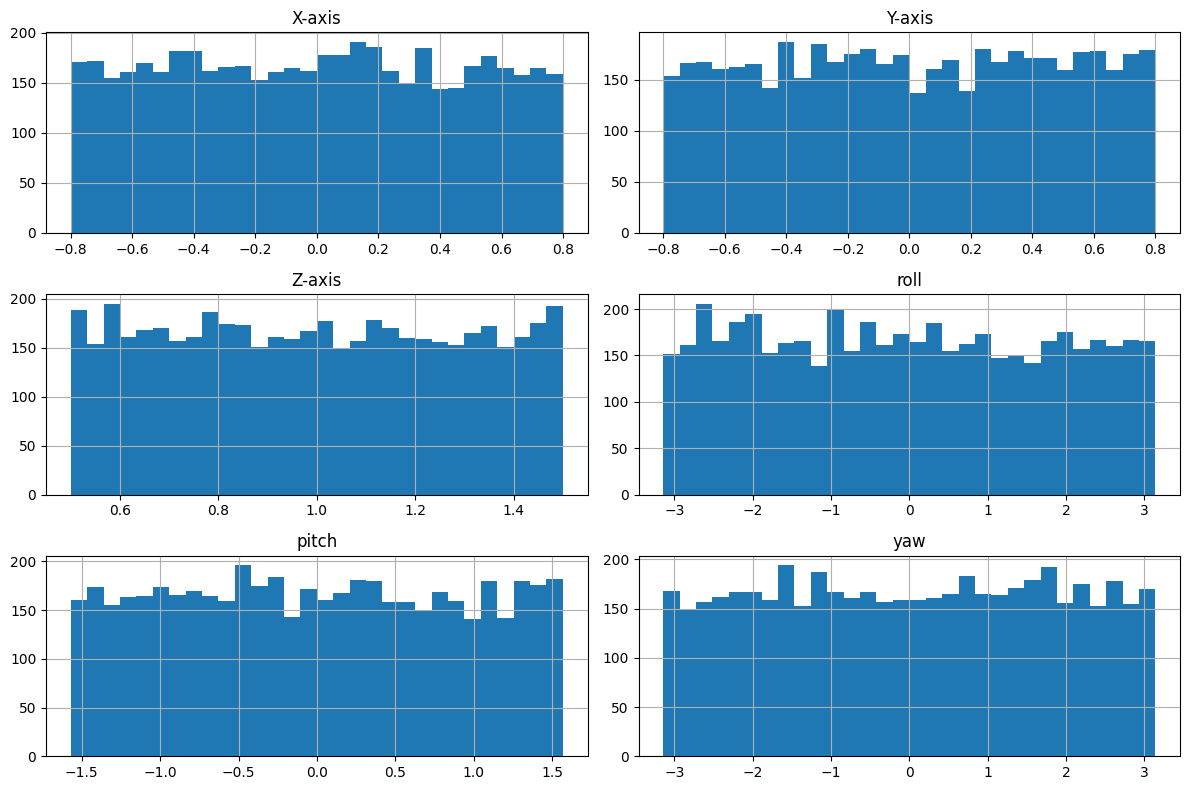

In [ ]:
# Numerical feature distribution
df.drop(columns=["Image_ID"]).hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


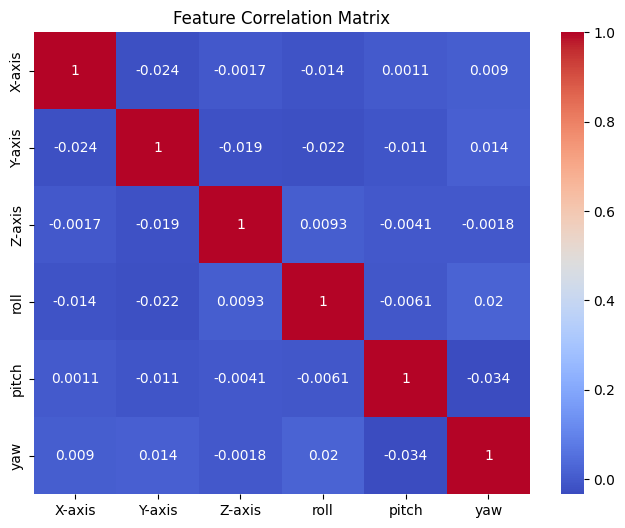

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=["Image_ID"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


**STEP 6: Missing Value Analysis**

In [ ]:
# Check missing values
df.isnull().sum()


,0
Image_ID,0
X-axis,0
Y-axis,0
Z-axis,0
roll,0
pitch,0
yaw,0


**STEP 7: Outlier Treatment (IQR Method)**

In [ ]:
# Impute missing numerical values using median
numerical_cols = df.columns.drop("Image_ID")

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values handled using median imputation.")


Missing values handled using median imputation.


In [ ]:
def iqr_outlier_treatment(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]


In [ ]:
for col in numerical_cols:
    df = iqr_outlier_treatment(df, col)

print("Outliers removed using IQR method.")
print("New shape:", df.shape)


Outliers removed using IQR method.
New shape: (5000, 7)


**STEP 8: Duplicate & Garbage Value Treatment**

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove physically impossible values (example: extreme angles)
angle_cols = ["roll", "pitch", "yaw"]
for col in angle_cols:
    df = df[df[col].between(-360, 360)]

print("Duplicates and garbage values removed.")


Duplicates and garbage values removed.


**STEP 9: Feature Scaling (StandardScaler)**

In [ ]:
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features normalized using StandardScaler.")
df_scaled.head()


Numerical features normalized using StandardScaler.


,Image_ID,X-axis,Y-axis,Z-axis,roll,pitch,yaw
0,img_000001.png,0.170759,-0.104822,-0.553851,0.209359,-0.326984,-0.774808
1,img_000002.png,1.087537,1.377196,-1.527417,-0.887401,1.210363,-0.742964
2,img_000003.png,1.656222,-1.110334,-1.487539,1.571732,-0.512054,-0.802920
3,img_000004.png,-0.187537,1.207895,0.195910,0.711385,-1.255655,0.949591
4,img_000005.png,-0.642871,-1.456886,0.100643,1.385461,-1.268425,-1.704788


**STEP 10: Final Data Validation**

In [ ]:
df_scaled.info()
df_scaled.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Image_ID  5000 non-null   object 
 1   X-axis    5000 non-null   float64
 2   Y-axis    5000 non-null   float64
 3   Z-axis    5000 non-null   float64
 4   roll      5000 non-null   float64
 5   pitch     5000 non-null   float64
 6   yaw       5000 non-null   float64
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


,X-axis,Y-axis,Z-axis,roll,pitch,yaw
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.563194e-17,3.126388e-17,-1.406875e-16,-3.268497e-17,-2.273737e-17,-2.273737e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.731751e+00,-1.749351e+00,-1.701172e+00,-1.706917e+00,-1.731932e+00,-1.749209e+00
25%,-8.683717e-01,-8.587376e-01,-8.618380e-01,-8.772653e-01,-8.578251e-01,-8.600651e-01
50%,1.783948e-02,-2.069700e-02,-5.216523e-03,-1.275062e-02,-1.289499e-02,7.961660e-03
75%,8.463498e-01,8.647238e-01,8.584908e-01,8.692500e-01,8.619052e-01,8.629540e-01
max,1.749201e+00,1.713375e+00,1.723796e+00,1.752910e+00,1.732985e+00,1.728432e+00


**STEP 11: Save the Processed Dataset**

In [ ]:
output_path = "pose_dataset_cleaned.csv"
df_scaled.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully at:")
print(output_path)


Cleaned dataset saved successfully at:
pose_dataset_cleaned.csv
